<font size="+3"><strong>Survey of Consumer Finances: Unsupervised Clustering </strong></font>

<font size="+2"><strong>Part 2: Clustering with Two Features</strong></font>

In [2]:
__author__ = "Donald Ghazi"
__email__ = "donald@donaldghazi.com"
__website__ = "donaldghazi.com"

In the the `Exploring the Data` project, I explored data from the [Survey of Consumer Finances](https://www.federalreserve.gov/econres/scfindex.htm) (SCF), paying special attention to households that have been turned down for credit or feared being denied credit. In this project, I'll build a model to segment those households into distinct clusters, and examine the differences between those clusters. 

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

GOALS
 - Subset my data to focus on "credit fearful" households.
     - Explore the relationship between debt and home value.
     - Build an unsupervised model to divide households into groups.
     - Examine the mean characteristics of each group.

Machine Learning Workflow
 - Prepare Data
     - Import
     - Explore
     - Split: No target vector
 - Build Model
     - Iterate
         - K-means model, choose number of clusters.
             - Clusters, centroids, inertia, silhouette score.
 - Communicate Results
     - Cluster centroids
     - Side-by-side bar chart

# Prepare Data

## Import
I need to begin by bringing my data into the project. I spent some time in the  `Exploring the Data` project working with a subset of the larger SCF dataset called `"TURNFEAR"`. I'll start with that.

**Wrangle Function**

In [3]:
# Create a wrangle function that takes a path of a CSV file as input, reads the file into a DataFrame, subsets the data to households that have been turned down for credit or feared being denied credit in the past 5 years (see "TURNFEAR"), and returns the subset DataFrame
def wrangle(filepath):
    df = pd.read_csv(filepath)
    mask = df["TURNFEAR"] == 1
    df = df[mask]
    return df

And now that I've got that taken care of, I'll import the data and see what I've got.

In [4]:
# Use my wrangle function to read the file SCFP2019.csv.gz into a DataFrame named df
df = wrangle("data/SCFP2019.csv.gz")
print(df.shape)
df.head()

(4623, 351)


,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
5,2,21,3790.476607,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
6,2,22,3798.868505,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,3,2,2
7,2,23,3799.468393,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
8,2,24,3788.076005,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
9,2,25,3793.066589,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2


## Explore

I looked at a lot of different features of the `"TURNFEAR"` subset in the the  `Exploring the Data` project, and the last thing I looked at was the relationship between real estate and debt. I'm going to make that graph again to refresh my memory on what that relationship looked like.

**Scatter Plot: Home vs Debt**

In [5]:
df["DEBT"].head()

5    12200.0
6    12600.0
7    15300.0
8    14100.0
9    15400.0
Name: DEBT, dtype: float64

In [6]:
(df["DEBT"] / 1_000_000).head()

5    0.0122
6    0.0126
7    0.0153
8    0.0141
9    0.0154
Name: DEBT, dtype: float64

In [7]:
(df["DEBT"] /1e6).head()

5    0.0122
6    0.0126
7    0.0153
8    0.0141
9    0.0154
Name: DEBT, dtype: float64

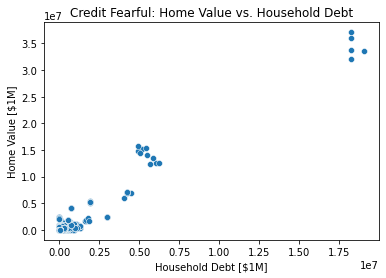

In [8]:
sns.scatterplot(x=df["DEBT"], y=df["HOUSES"])
plt.xlabel("Household Debt [$1M]") 
plt.ylabel("Home Value [$1M]") 
plt.title("Credit Fearful: Home Value vs. Household Debt");

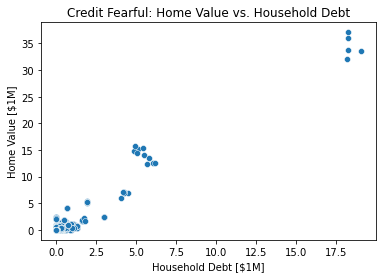

In [9]:
# Create a scatter plot of that shows the total value of primary residence of a household ("HOUSES") as a function of the total value of household debt ("DEBT")
sns.scatterplot(x=df["DEBT"]/1e6, y=df["HOUSES"]/1e6)
plt.xlabel("Household Debt [$1M]") # Label x-axis as "Household Debt"
plt.ylabel("Home Value [$1M]") # Label y-axis as "Home Value"
plt.title("Credit Fearful: Home Value vs. Household Debt"); # Title "Credit Fearful: Home Value vs. Household Debt"

## Split

I need to split my data, but I'm not going to need target vector or a test set this time around. That's because the model I'll be building involves *unsupervised* learning. It's called *unsupervised* because the model doesn't try to map input to a st of labels or targets that already exist.

**Vertical Split**

In [10]:
# Create the feature matrix X
X = df[["DEBT", "HOUSES"]] # Should contain two features only: "DEBT" and "HOUSES"
print(X.shape)
X.head()

(4623, 2)


,DEBT,HOUSES
5,12200.0,0.0
6,12600.0,0.0
7,15300.0,0.0
8,14100.0,0.0
9,15400.0,0.0


# Build Model

**Unsupervised Learning & K-Means**

In [11]:
cw = ClusterWidget(n_clusters=3)
cw.show()

At the first position, there's whole bunch of gray datapoints, and if I look carefully, I'll see there are also three stars. Those stars are the **centroids**. At first, their position is set randomly. If I move the slider one more position to the right, I'll see all the gray points change colors that correspond to three clusters.

Since a centroid represents the mean value of all the data in the cluster, I would expect it to fall in the center of whatever cluster it's in. That's what will happen if I move the slider one more position to the right. 

But since they moved, the datapoints might not be in the right clusters anymore. Moving the slider again, and I'll see the data points redistribute themselves to better reflect the new position of the centroids. The new clusters mean that the centroids also need to move, which will lead to the clusters changing again, and so on, until all the datapoints end up in the right cluster with a centroid that reflects the mean value of all those points.

I'll see what happens when I try the same with my `"DEBT"` and `"HOUSES"` data.

**K-Means: SCF Example**

In [12]:
scfc = SCFClusterWidget(x=df["DEBT"], y=df["HOUSES"], n_clusters=3)
scfc.show()

## Iterate

Now that I've had a chance to play around with the process a little bit, I'll get into building a model that does the same thing.

**Build Model**

I'll build a `KMeans` model, assign it to the variable name `model`, and fit it to the training data `X`. 

In [50]:
# Build model
model = KMeans(n_clusters=3, random_state=42)
# Fit model to data
model.fit(X)

KMeans(n_clusters=3, random_state=42)

42 datapoints spread across three clusters. I'll grab the labels that the model has assigned to the data points so I can start making a new visualization.

**Extract Cluster Labels**

In [51]:
# Extract the labels that my model created during training and assign them to the variable labels
labels = model.labels_
labels[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [52]:
labels = model.labels_
labels[-10:]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

Using the labels I just extracted, I'll recreate the scatter plot from before, this time I'll color each point according to the cluster to which the model assigned it.

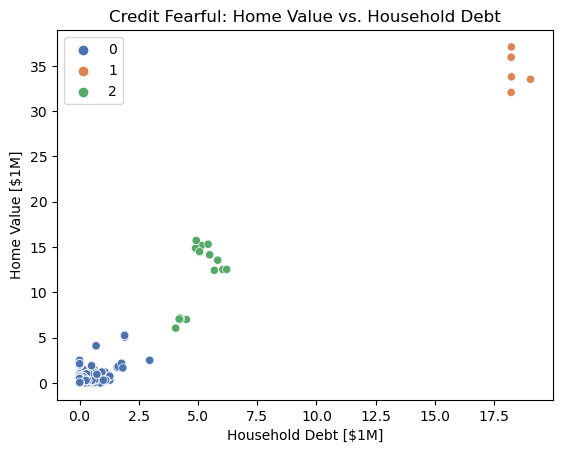

In [53]:
# Plot "HOUSES" vs "DEBT" with hue=label
sns.scatterplot(
    x=df["DEBT"]/1e6,
    y=df["HOUSES"]/1e6,
    hue=labels,
    palette="deep"
)
plt.xlabel("Household Debt [$1M]")
plt.ylabel("Home Value [$1M]")
plt.title("Credit Fearful: Home Value vs. Household Debt");

Each cluster has its own color. The centroids are still missing, so I'll pull those out.

**Extract Centroids**

In [54]:
# Extract the centroids that my model created during training, and assign them to the variable centroids
centroids = model.cluster_centers_
centroids

array([[   91017.57766674,   116150.29328698],
       [18384100.        , 34484000.        ],
       [ 5065800.        , 11666666.66666667]])

I'll add the centroids to the graph.

**Plot Centroids**

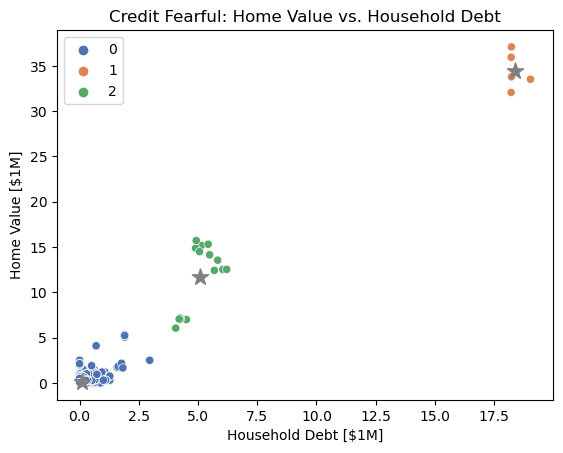

In [55]:
# Plot "HOUSES" vs "DEBT", add centroids
sns.scatterplot(
    x=df["DEBT"]/1e6,
    y=df["HOUSES"]/1e6,
    hue=labels,
    palette="deep"
)
plt.scatter(
    x=centroids[:, 0]/1e6,
    y=centroids[:, 1]/1e6,
    color="gray",
    marker="*",
    s=150
)
plt.xlabel("Household Debt [$1M]")
plt.ylabel("Home Value [$1M]")
plt.title("Credit Fearful: Home Value vs. Household Debt");

Even though my graph makes it *look* like the clusters are correctly assigned but I need a numerical evaluation. The data I'm using is pretty clear-cut, but if things were a little more muddled, I'd want to run some calculations to make sure I got everything right.

There are two metrics that I'll use to evaluate my clusters. I'll start with **inertia**, which measure the distance between the points *within the same cluster*. 

**Intertia**

In [56]:
# Extract the inertia for my model and assign it to the variable inertia
inertia = model.inertia_
print("Inertia (3 clusters):", inertia)

Inertia (3 clusters): 939554010797059.4


The "best" inertia is 0, and my score is pretty far from that. Does that mean my model is "bad?" Not necessarily. Inertia is a measurement of distance (like mean absolute error). This means that the unit of measurement for inertia depends on the unit of measurement of my x- and y-axes. And since `"DEBT"` and `"HOUSES"` are measured in tens of millions of dollars, it's not surprising that inertia is so large. 

However, it would be helpful to have metric that was easier to interpret, and that's where **silhouette score** comes in. Silhouette score measures the distance *between different clusters*. It ranges from -1 (the worst) to 1 (the best), so it's easier to interpret than inertia. 

**Silhouette Score**

In [57]:
# Calculate the silhouette score for my model and assign it to the variable ss
ss = silhouette_score(X, model.labels_)
print("Silhouette Score (3 clusters):", ss)

Silhouette Score (3 clusters): 0.9768842462944348


0.976 is pretty close to 1, so my model has done a good job at identifying 3 clusters that are far away from each other.

These performance metrics are the result of the number of clusters I told my model to create. In unsupervised learning, the number of clusters is hyperparameter that I set before training my model. So what would happen if I change the number of clusters? Will it lead to better performance? I'll give it a shot here.

**Finding the Best K**

I'll use a `for` loop to build and train a K-Means model where `n_clusters` ranges from 2 to 12 (inclusive). Each time a model is trained, I'll calculate the inertia and add it to the list `inertia_errors`, then calculate the silhouette score and add it to the list `silhouette_scores`.

In [58]:
n_clusters = range(2, 13)
inertia_errors = []
silhouette_scores = []

# Add `for` loop to train model and calculate inertia, silhouette score.
for k in n_clusters:
    # Build model
    model = KMeans(n_clusters=k, random_state=42)
    # Train model
    model.fit(X)
    # Calculate inertia
    inertia_errors.append(model.inertia_)
    # Calculate ss
    silhouette_scores.append(silhouette_score(X, model.labels_))


print("Inertia:", inertia_errors)
print()
print("Silhouette Scores:", silhouette_scores)

Inertia: [3018038313336857.5, 939554010797059.4, 546098841715646.25, 309310386410913.3, 235243397481784.3, 182225729179703.53, 150670779013790.4, 114321995931021.89, 100340259483919.02, 86229997033602.88, 74757234072100.36]

Silhouette Scores: [0.9855099957519555, 0.9768842462944348, 0.9490311483406091, 0.839330043242819, 0.7287406719898627, 0.726989114305748, 0.7263840026889208, 0.7335125606476427, 0.692157992955073, 0.6949309528556856, 0.6951831031001252]


Now that I have both performance metrics for several different settings of `n_clusters`, I'll make some line plots to see the relationship between the number of clusters in a model and its inertia and silhouette scores.

**Intertia vs Clusters**

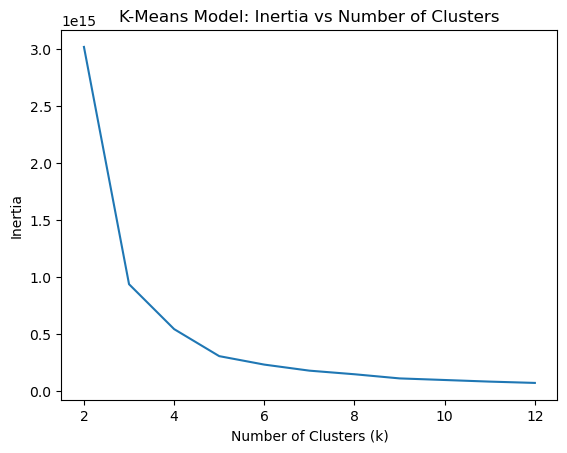

In [59]:
# Create a line plot that shows the values of inertia_errors as a function of n_clusters
plt.plot(n_clusters, inertia_errors)
plt.xlabel("Number of Clusters (k)") # Label x-axis "Number of Clusters"
plt.ylabel("Inertia") # Label y-axis "Inertia"
plt.title("K-Means Model: Inertia vs Number of Clusters"); # Title "K-Means Model: Inertia vs Number of Clusters"

What I'm seeing here is that, as the number of clusters increases, inertia goes down. In fact, I could get inertia to 0 if I told my model to make 4,623 clusters (the same number of observations in `X`), but those clusters wouldn't be helpful to me.

The trick with choosing the right number of clusters is to look for the "bend in the elbow" for this plot. In other words, I want to pick the point where the drop in inertia becomes less dramatic and the line begins to flatten out. In this case, it looks like the sweet spot is 4 or 5. 

I'll see what the silhouette score looks like. 

**Silhouette Score vs Clusters**

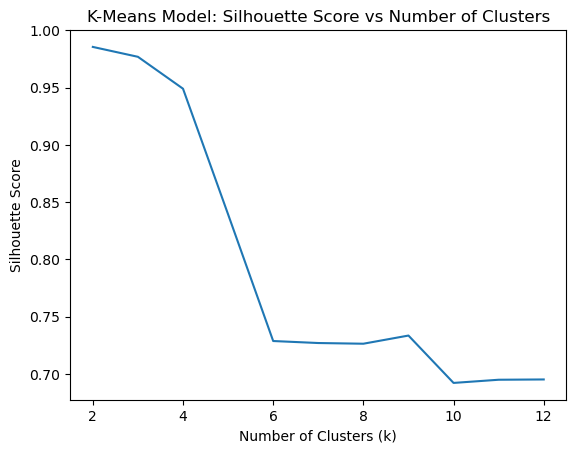

In [60]:
# Create a line plot that shows the values of silhouette_scores as a function of n_clusters
plt.plot(n_clusters, silhouette_scores)
plt.xlabel("Number of Clusters (k)")  # Label x-axis "Number of Clusters"
plt.ylabel("Silhouette Score")    # Label y-axis "Silhouette Score"
plt.title("K-Means Model: Silhouette Score vs Number of Clusters"); # Title "K-Means Model: Silhouette Score vs Number of Clusters"

Note that, in contrast to my inertia plot, bigger is better. So I'm not looking for a "bend in the elbow" but rather a number of clusters for which the silhouette score still remains high. I can see that silhouette score drops drastically beyond 4 clusters. Given this and what I saw in the inertia plot, it looks like the optimal number of clusters is 4. 

Now that I've decided on the final number of clusters, I'll build a final model.

**Build Final Model**

I'll build and train a new k-means model named `final_model`. I'll use the information I gained from the two plots above to set an appropriate value for the `n_clusters` argument.

In [61]:
# Build model
final_model = KMeans(n_clusters=4, random_state=42)
# Fit model to data
final_model.fit(X)

KMeans(n_clusters=4, random_state=42)

In [62]:
final_model.algorithm

'lloyd'

I don't need an *Evaluate* section in this project because I don't have any test data to evaluate my model with.)

# Communicate

**Plot Final Clusters**

Now I want to create one last "Home Value vs. Household Debt" scatter plot that shows the clusters that my`final_model` has assigned to the training data. 

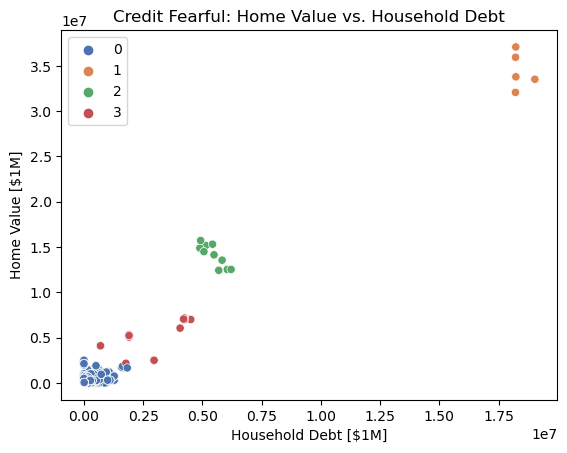

In [63]:
# Plot "HOUSES" vs "DEBT" with final_model labels
sns.scatterplot(
    x=df["DEBT"],
    y=df["HOUSES"],
    hue=final_model.labels_,
    palette="deep"
)
plt.xlabel("Household Debt [$1M]")
plt.ylabel("Home Value [$1M]")
plt.title("Credit Fearful: Home Value vs. Household Debt");

I can see all four of my clusters, each differentiated from the rest by color.

I'm going to make one more visualization, converting the cluster analysis I just did to something a little more actionable: a side-by-side bar chart. In order to do that, I need to put my clustered data into a DataFrame.

**Side-by-Side Bar Chart: Get Centroids**

In [64]:
xgb = X.groupby(final_model.labels_)
xgb

In [65]:
# Create a DataFrame xgb that contains the mean "DEBT" and "HOUSES" values for each of the clusters in my final_model
xgb = X.groupby(final_model.labels_).mean()
xgb

,DEBT,HOUSES
0,8.488629e+04,1.031872e+05
1,1.838410e+07,3.448400e+07
2,5.472800e+06,1.407400e+07
3,2.420929e+06,4.551429e+06


In [66]:
final_model.cluster_centers_

array([[   84886.28951384,   103187.22476563],
       [18384100.        , 34484000.        ],
       [ 5472800.        , 14074000.        ],
       [ 2420928.57142857,  4551428.57142857]])

Before going further, I'm going to print out the `cluster_centers_` for my `final_model`.

**Side-by-Side Bar Chart: Build Chart**

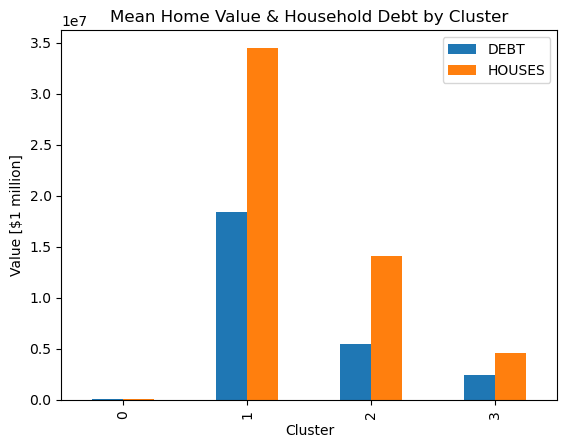

In [67]:
xgb.plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Value [$1 million]")
plt.title("Mean Home Value & Household Debt by Cluster");

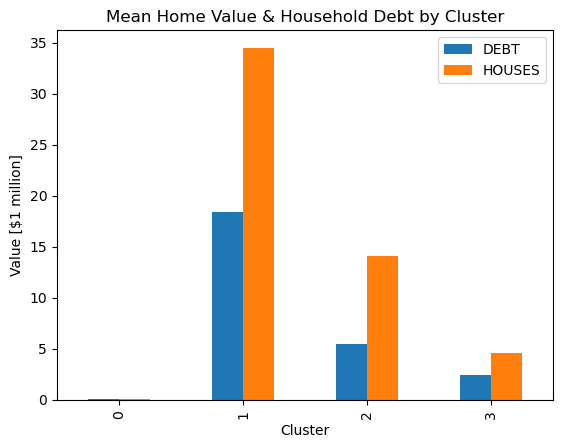

In [68]:
# Create a side-by-side bar chart from xgb that shows the mean "DEBT" and "HOUSES" values for each of the clusters in my final_model
(xgb/1e6).plot(kind="bar")  # Divide the values in xgb by 1 million for readability
plt.xlabel("Cluster") # Label the x-axis "Cluster"
plt.ylabel("Value [$1 million]") # Label the y-axis "Value [$1 million]"
plt.title("Mean Home Value & Household Debt by Cluster");

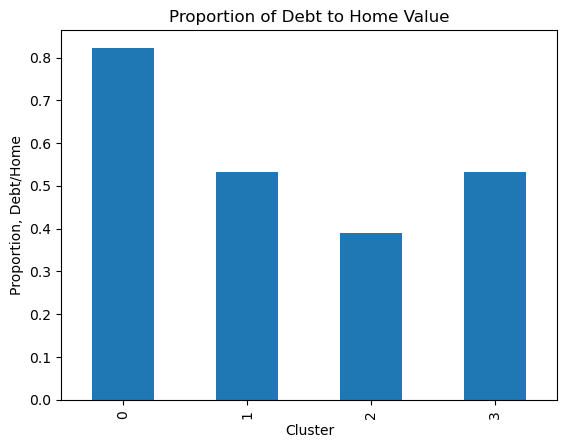

In [69]:
(xgb["DEBT"] / xgb["HOUSES"]).plot(
    kind="bar",
    xlabel="Cluster",
    ylabel="Proportion, Debt/Home",
    title="Proportion of Debt to Home Value"
);

In this plot, I have my four clusters spread across the x-axis, and the dollar amounts for home value and household debt on the y-axis. 

The first thing to look at in this chart is the different mean home values for the five clusters. Clusters 0 represents households with small to moderate home values, clusters 2 and 3 have high home values, and cluster 1 has extremely high values. 

The second thing to look at is the proportion of debt to home value. In clusters 1 and 3, this proportion is around 0.5. This suggests that these groups have a moderate amount of untapped equity in their homes. But for group 0, it's almost 1, which suggests that the largest source of household debt is their mortgage. Group 2 is unique in that they have the smallest proportion of debt to home value, around 0.4.

This information could be useful to financial institution that want to target customers with products that would appeal to them. For instance, households in group 0 might be interested in refinancing their mortgage to lower their interest rate. Group 2 households could be interested in a [home equity line of credit](https://www.investopedia.com/home-equity-line-of-credit-heloc-definition-5217473) because they have more equity in their homes. And the bankers, Bill Gates, and Beyoncés in group 1 might want white-glove personalized wealth management. 